<a href="https://colab.research.google.com/github/s-bishal/ML-Lab/blob/main/ML_Lab_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multiple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

path="food_coded.csv"

df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"borapajo/food-choices",path)

df.head()

100%|██████████| 70.9k/70.9k [00:00<00:00, 956kB/s]


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


### Data Preparation for Multiple Linear Regression

In [6]:
import statsmodels.api as sm

# Select relevant numerical columns for regression
# Using 'GPA' as dependent variable and a few calorie columns as independent variables
regression_cols = ['GPA', 'calories_chicken', 'calories_day', 'calories_scone']
reg_df = df[regression_cols].copy()

# Convert selected columns to numeric, coercing errors to NaN
for col in regression_cols:
    reg_df[col] = pd.to_numeric(reg_df[col], errors='coerce')

# Drop rows with any missing values in the selected columns after conversion
reg_df.dropna(inplace=True)

print("Shape of DataFrame after dropping NaNs and converting to numeric:", reg_df.shape)
display(reg_df.head())

Shape of DataFrame after dropping NaNs and converting to numeric: (101, 4)


,GPA,calories_chicken,calories_day,calories_scone
1,3.654,610,3.0,420.0
2,3.300,720,4.0,420.0
3,3.200,430,3.0,420.0
4,3.500,720,2.0,420.0
5,2.250,610,3.0,980.0


### Perform Multiple Linear Regression

In [7]:
# Define dependent (y) and independent (X) variables
y = reg_df['GPA'].astype(float) # Explicitly cast to float
X = reg_df[['calories_chicken', 'calories_day', 'calories_scone']].astype(float) # Explicitly cast to float

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X)
results = model.fit()

# Print the regression summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     2.087
Date:                Sat, 08 Aug 2026   Prob (F-statistic):              0.107
Time:                        14:03:45   Log-Likelihood:                -44.819
No. Observations:                 101   AIC:                             97.64
Df Residuals:                      97   BIC:                             108.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.3282      0.221  

### Visualize Regression Results

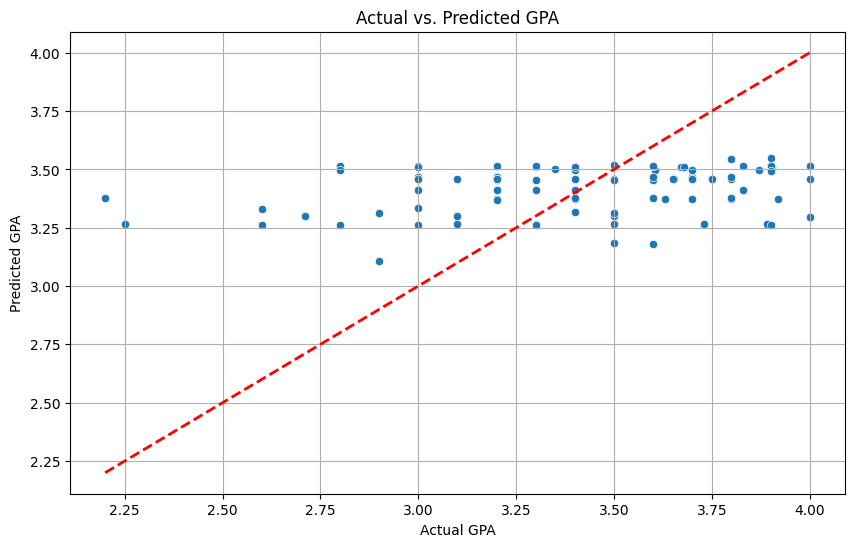

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted values
reg_df['predicted_GPA'] = results.predict(X)

# Plot actual vs predicted GPA
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='GPA', y='predicted_GPA', data=reg_df, ax=ax)
ax.plot([reg_df['GPA'].min(), reg_df['GPA'].max()], [reg_df['GPA'].min(), reg_df['GPA'].max()], 'r--', lw=2)
plt.title('Actual vs. Predicted GPA')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.grid(True)
plt.show()

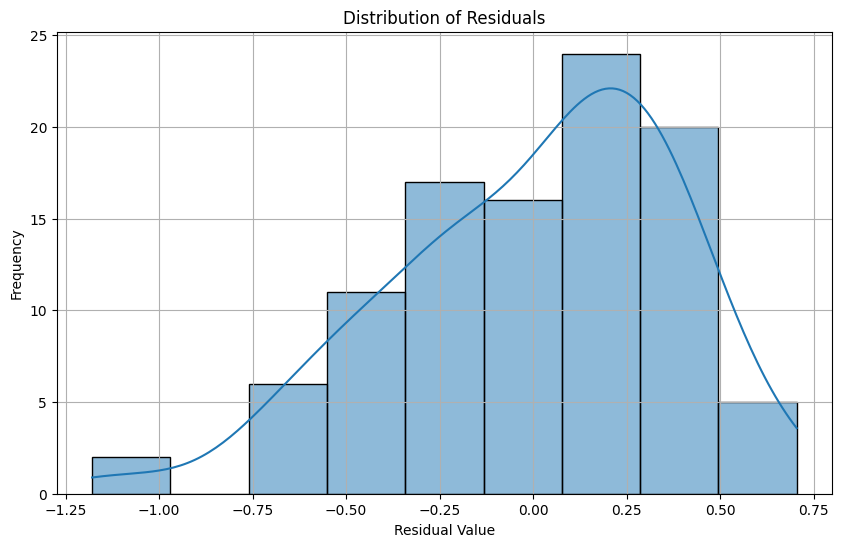

In [9]:
import matplotlib.pyplot as plt

# Plot residuals
residuals = results.resid
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(residuals, kde=True, ax=ax)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()